In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## general libraries
import pathlib
from rich.pretty import install, pprint

## data handling libraries
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.dask import TqdmCallback as ProgressBarDask

# plotting libraries
import matplotlib.pyplot as plt

## machine learning libraries
import gpytorch 
import torch
import ngboost
from sklearn import metrics
from sklearn import ensemble as trees

## PAMIR libraries
import mlflow
import hydra
import pamir_mlpermafrost as pamir
from cryogrid_pytools import xr_raster_vector

install(overflow=True)

In [3]:
cfg = pamir.utils.load_hydra_config(
    config_dir='../../src/pamir_mlpermafrost/conf', 
    config_name='jupyter-multi',)

2025-08-19 14:22:35 | WARNING  - Will pop `run_dir` since detected in Notebook and cant be resolved


In [4]:
data = cfg.data.training.load().loc[["S180_exp4", "N180_exp4"]]
data = data.reset_index().set_index(["y", "x"])

# Preprocess the data
data_X, data_y = cfg.preprocessing.training(data)

# Split the data into training and testing sets
train_X, test_X, train_y, test_y = cfg.preprocessing.train_test_split(
    data_X, data_y
)

# Scale the features and target variable
scaler_X = cfg.scalers.features.fit(train_X)
scaler_y = cfg.scalers.target.fit(train_y)

train_X_scaled = scaler_X.transform(train_X).to(cfg.device)
train_y_scaled = scaler_y.transform(train_y).squeeze().to(cfg.device)
test_X_scaled = scaler_X.transform(test_X).to(cfg.device)
test_y_scaled = scaler_y.transform(test_y).squeeze().to(cfg.device)

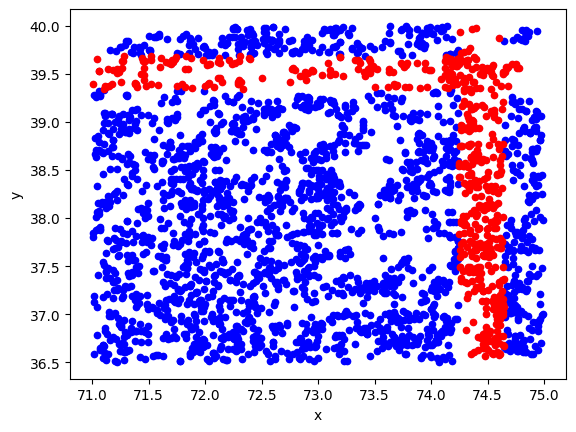

In [5]:
ax = data_X.reset_index().plot.scatter(x='x', y='y', c='b', alpha=0.2)
ax = train_X.reset_index().plot.scatter(x='x', y='y', c='b', ax=ax)
ax = test_X.reset_index().plot.scatter(x='x', y='y', c='r', ax=ax)

In [6]:
class MultitaskGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(MultitaskGPModel, self).__init__(train_x, train_y, likelihood)
        
        num_tasks = train_y.shape[1]

        self.mean_module = gpytorch.means.MultitaskMean(
            gpytorch.means.ConstantMean(), num_tasks=num_tasks
        )
        self.covar_module = gpytorch.kernels.MultitaskKernel(
            gpytorch.kernels.RBFKernel(), num_tasks=num_tasks, rank=1
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultitaskMultivariateNormal(mean_x, covar_x)
    
likelihood = cfg.likelihood()
model = cfg.model(train_X_scaled, train_y_scaled, likelihood=likelihood).to(device=cfg.device)

In [7]:
model.fit(
    train_X_scaled, 
    train_y_scaled, 
    cfg.optimizer(model.parameters()),
    n_iters=20,
)

ic| y_train_scaled_tensor.shape: torch.Size([2282, 24])


2025-08-19 14:22:42 | INFO     - Iter 10/20 - Loss: 1.812251
2025-08-19 14:22:45 | INFO     - Iter 20/20 - Loss: 1.710499



(
    GPCustomCovarMultitask(
  (likelihood): MultitaskGaussianLikelihood(
    (raw_task_noises_constraint): Interval(2.000E-01, 5.000E+00)
    (raw_noise_constraint): Interval(2.000E-01, 5.000E+00)
  )
  (mean_module): ConstantMean()
  (covar_module): MultitaskKernel(
    (task_covar_module): IndexKernel(
      (raw_var_constraint): Positive()
    )
    (data_covar_module): ScaleKernel(
      (base_kernel): RBFKernel(
        (raw_lengthscale_constraint): Positive()
      )
      (raw_outputscale_constraint): Positive()
    )
  )
  (constant_mean): MultitaskMean(
    (base_means): ModuleList(
      (0-23): 24 x ConstantMean()
    )
  )
),
    [
        1.8919005393981934,
        1.883607029914856,
        1.8750938177108765,
        1.8665238618850708,
        1.8578346967697144,
        1.8489854335784912,
        1.839996337890625,
        1.8308824300765991,
        1.8216392993927002,
        1.8122509717941284,
        1.8027092218399048,
        1.7930183410644531,
        1.7

In [8]:
# Set into eval mode
model.eval()
likelihood.eval()


MultitaskGaussianLikelihood(
  (raw_task_noises_constraint): Interval(2.000E-01, 5.000E+00)
  (raw_noise_constraint): Interval(2.000E-01, 5.000E+00)
)

In [9]:
class CustomData(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [10]:
dataset = CustomData(train_X_scaled, train_y_scaled)

In [11]:
dataloader = torch.utils.data.DataLoader(
    dataset,
    shuffle=True
)

In [12]:
# Make predictions
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    for batch_X, batch_y in dataloader:
        batch_X = batch_X.to(cfg.device)
        predictions = likelihood(model(batch_X))
        mean = predictions.mean
        lower, upper = predictions.confidence_region()


OutOfMemoryError: CUDA out of memory. Tried to allocate 11.18 GiB. GPU 0 has a total capacity of 11.90 GiB of which 316.62 MiB is free. Process 1471683 has 11.59 GiB memory in use. Of the allocated memory 11.23 GiB is allocated by PyTorch, and 27.37 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)